#### CORS AND SECURITY HEADERS



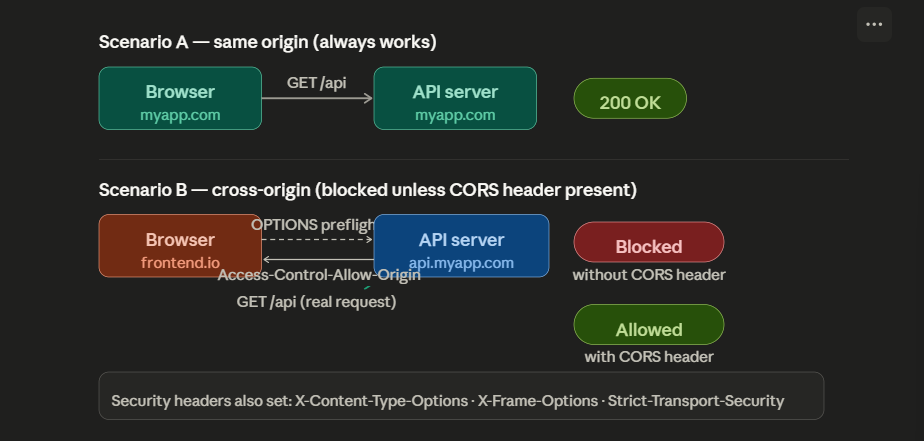

Analogy:

A restaurant the api server will happily serve anyone who walks in through its own door (same origin)

but if a delievery driver from another company a different domain shows up asking to collect orders

1. we first check if they are approved list of delivery partners?

2. if yes hand over the food , if not they refuse

security headers are like restaurants posted policies on the wall:

1. No photos of kitchen (X-Frame-Options)

2. Only accept typed menus not handwritten ones



In [24]:
from fastapi import FastAPI
from fastapi.middleware.cors import CORSMiddleware
from fastapi.middleware.httpsredirect import HTTPSRedirectMiddleware
from starlette.middleware.base import BaseHTTPMiddleware
from starlette.requests import Request

app = FastAPI()


#cors middleware
#this is the approved delivery partner list

app.add_middleware(
    CORSMiddleware,
    allow_origins=[
        "https://myapp.com",
        "https://www.myapp.com",
    ],

    #whether to allow cookies
    allow_credentials = True,
    allow_methods = ["GET","POST","PUT","DELETE"],
    allow_headers = ["Authorization","Content-Type"],
)

#Security Headers middleware

class SecurityHeadersMiddleware(BaseHTTPMiddleware):
    async def dispatch(self, request: Request, call_next):
        response = await call_next(request)

        # Don't let your API be embedded in an <iframe> (prevents clickjacking)
        response.headers["X-Frame-Options"] = "DENY"

        # Prevent browsers from guessing content type (stops MIME sniffing attacks)
        response.headers["X-Content-Type-Options"] = "nosniff"

        # Force HTTPS for 1 year, include subdomains
        response.headers["Strict-Transport-Security"] = (
            "max-age=31536000; includeSubDomains"
        )

        # Restrict what external resources the page can load
        response.headers["Content-Security-Policy"] = (
            "default-src 'self'; "     # only load resources from same origin
            "script-src 'self'; "      # no external scripts
            "object-src 'none'"        # no Flash, no plugins
        )

        # Don't send Referer header when following links out
        response.headers["Referrer-Policy"] = "strict-origin-when-cross-origin"

        return response

app.add_middleware(SecurityHeadersMiddleware)

@app.get("/")
async def root():
    return {"message": "Running with CORS + security headers!"}


#### protecting sensitive information

1. always use HTTPS instead of HTTP for secure communication, as https encrypts data during transmission

2. hashing passwords: Never store passwords in plain text, always hash passwords using a strong algorithm such as bcrypt.

3. Encrpty sensitive data

4. use env